# Lasso Regul points with example

## 1. How are coefficients affected

In [3]:
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
df.sample(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
393,-0.074533,-0.044642,-0.046085,-0.043542,-0.029088,-0.023234,0.015505,-0.039493,-0.039809,-0.021788,69.0
132,0.016281,0.050680,-0.021295,-0.009113,0.034206,0.047850,0.000779,-0.002592,-0.012909,0.023775,107.0
431,0.070769,0.050680,-0.030996,0.021872,-0.037344,-0.047034,0.033914,-0.039493,-0.014960,-0.001078,66.0
386,0.019913,-0.044642,-0.040696,-0.015999,-0.008449,-0.017598,0.052322,-0.039493,-0.030748,0.003064,72.0
348,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078,148.0


In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=14)

In [14]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

coefs = []
r2_scores = []

for alpha in [0, 0.1, 1, 10]:
    lso = Lasso(alpha=alpha)
    lso.fit(x_train, y_train)
    y_pred = lso.predict(x_test)

    coefs.append(lso.coef_.tolist())
    r2_scores.append(r2_score(y_pred, y_test))

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.016e+05, tolerance: 2.080e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


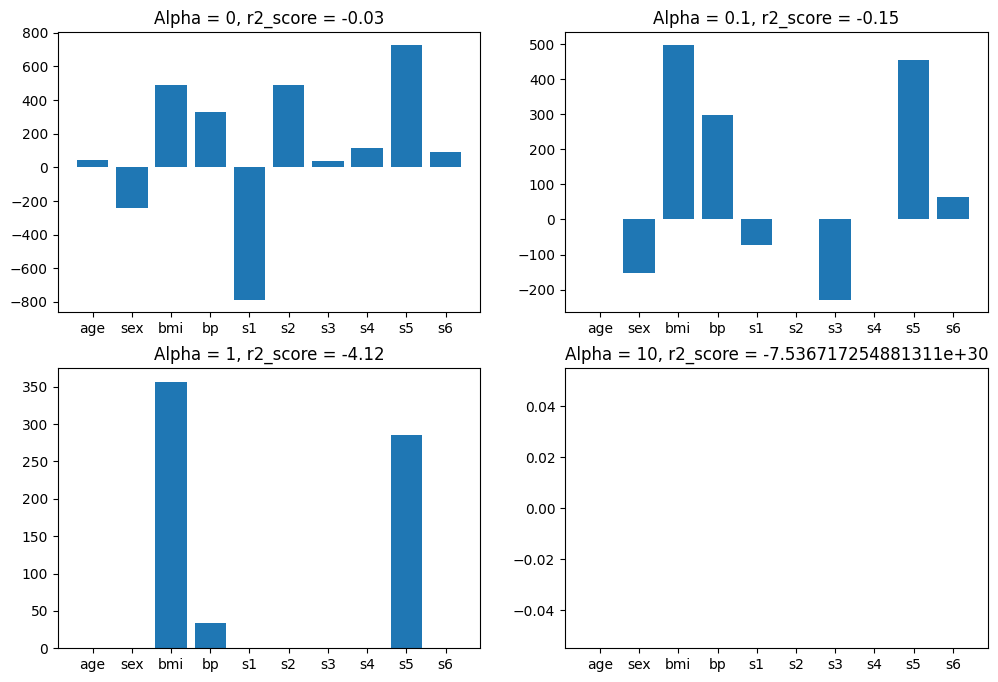

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
 
plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title('Alpha = 0, r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title('Alpha = 0.1, r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title('Alpha = 1, r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names, coefs[3])
plt.title('Alpha = 10, r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

## 2. Higher coefficients are affected more.

In [28]:
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
coefs = []

for alpha in alphas:
    lso = Lasso(alpha=alpha)
    lso.fit(x_train, y_train)
    coefs.append(lso.coef_)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.016e+05, tolerance: 2.080e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [29]:
import numpy as np
input_array = np.array(coefs)

coefs_df = pd.DataFrame(input_array, columns=data.feature_names)
coefs_df['Alpha'] = alphas
coefs_df.set_index('Alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
Alpha,,,,,,,,,,
0.0000,44.193557,-240.021294,490.287383,331.888530,-785.793979,487.644193,35.197867,112.936180,727.171479,91.005548
0.0001,44.144492,-239.913629,490.348853,331.824915,-779.084205,482.635317,31.847686,111.494599,724.748540,91.036026
0.0010,43.702966,-238.944792,490.901773,331.252499,-718.720923,437.574257,1.707647,98.524492,702.951249,91.310221
0.0100,39.543240,-227.884848,497.699235,326.278541,-340.114659,140.179924,-160.608835,45.974219,561.621249,91.318841
0.1000,0.000000,-153.268342,497.385685,296.969791,-74.126531,-0.000000,-228.398556,0.000000,455.368238,64.634411
1.0000,0.000000,-0.000000,356.757547,33.789257,0.000000,0.000000,-0.000000,0.000000,284.720264,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


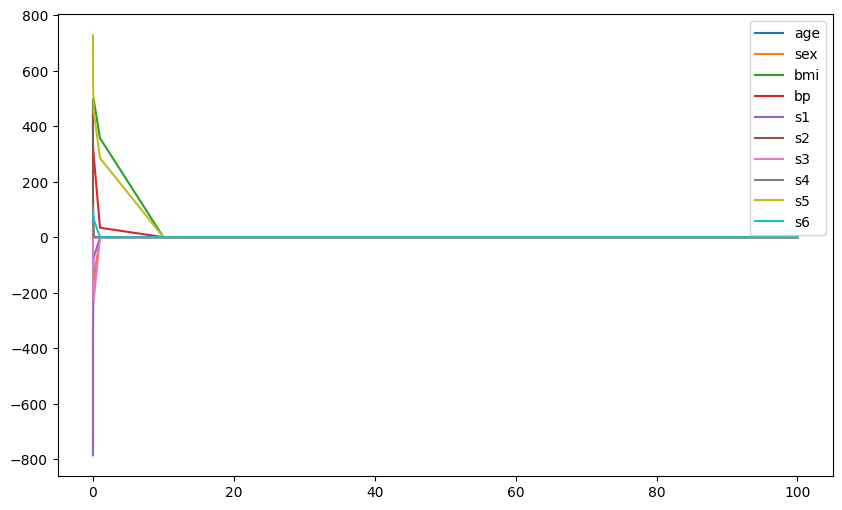

In [34]:
input_array = np.array(coefs).T

plt.figure(figsize=(10,6))
plt.plot(alphas, np.zeros(len(alphas)), color='black')
for i in range(input_array.shape[0]):
    plt.plot(alphas, input_array[i], label=data.feature_names[i])

plt.legend()
plt.show()

## 3. Impact on bias and variance

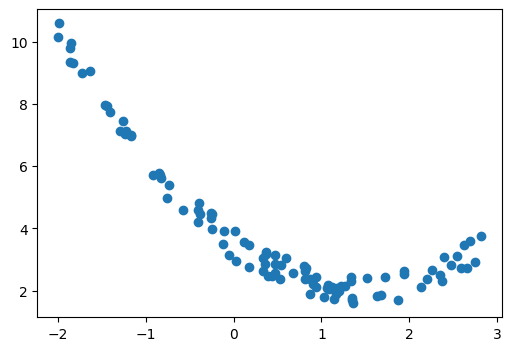

In [40]:
m = 100
x = 5*np.random.rand(m, 1) - 2
y = 0.7* x**2 - 2*x + 3 + np.random.rand(m, 1)

plt.figure(figsize=(6,4))
plt.scatter(x, y)

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x.reshape(100,1), y.reshape(100), test_size=0.2, random_state=14)

In [42]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [48]:
!pip install mlxtend

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)


In [50]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0, 30, 100)

loss = []
bias = []
variance = []

for i in alphas:
    lso = Lasso(alpha=i)
    avg_loss, avg_bias, avg_var = bias_variance_decomp(
        lso, x_train, y_train, x_test, y_test,
        loss = 'mse',
        random_seed = 123
    )
    loss.append(avg_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.030e+01, tolerance: 3.572e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
E:\Anacon

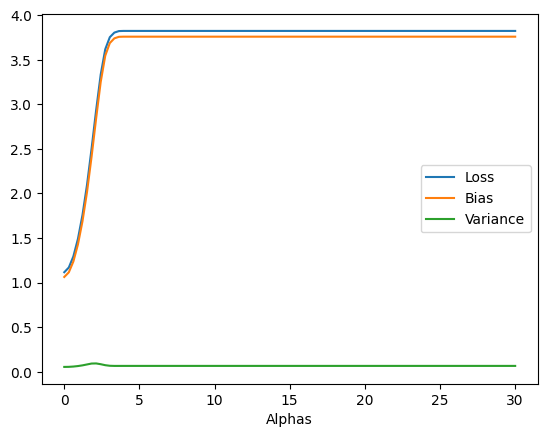

In [51]:
plt.plot(alphas, loss, label='Loss')
plt.plot(alphas, bias, label='Bias')
plt.plot(alphas, variance, label='Variance')
plt.xlabel('Alphas')
plt.legend()

## 4. Effect of Regularization on loss function

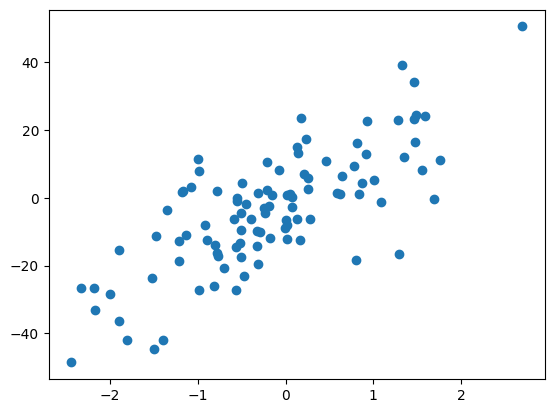

In [53]:
from sklearn.datasets import make_regression

x, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=10, random_state=14)
plt.scatter(x, y)

In [54]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x, y)
print('Coef =', lin_reg.coef_)
print('Intercept =', lin_reg.intercept_)

Coef = [12.97737907]
Intercept = -1.416505862944328


In [55]:
def calc_loss(m, alpha):
    return np.sum((y - m*x.ravel() - 1.41)**2) + alpha*abs(m)

In [56]:
def predict(m):
    return m*x - 1.41

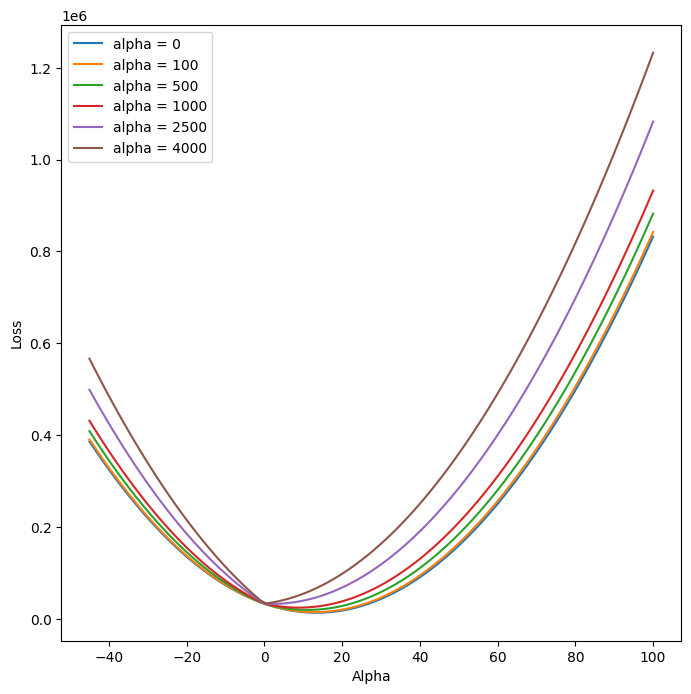

In [62]:
m = np.linspace(-45, 100, 100)
plt.figure(figsize=(8, 8))

for i in [0, 100, 500, 1000, 2500, 4000]:
    loss = []
    for j in range(m.shape[0]):
        loss_j = calc_loss(m[j], i)
        loss.append(loss_j)
    plt.plot(m, loss, label='alpha = {}'.format(i))

plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()